In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 파일 읽기 (n 섹션과 k 섹션을 각각 파싱)
with open('../data/Si_Green2008.csv', 'r') as f:
    lines = f.readlines()

# 빈 줄을 기준으로 n 섹션과 k 섹션 나누기
split_idx = [i for i, line in enumerate(lines) if line.strip() == ''][0]

n_lines = lines[1:split_idx]        # 첫 줄(wl,n)은 헤더라 제외
k_lines = lines[split_idx+2:]       # 빈줄 다음 줄(wl,k)도 헤더라 제외

wl_n, n_vals = np.loadtxt(n_lines, delimiter=',', unpack=True)
wl_k, k_vals = np.loadtxt(k_lines, delimiter=',', unpack=True)

print(f"n 데이터 개수: {len(wl_n)}, k 데이터 개수: {len(wl_k)}")
print(f"n 파장 범위: {wl_n.min()} ~ {wl_n.max()} μm")
print(f"k 파장 범위: {wl_k.min()} ~ {wl_k.max()} μm")


n 데이터 개수: 121, k 데이터 개수: 121
n 파장 범위: 0.25 ~ 1.45 μm
k 파장 범위: 0.25 ~ 1.45 μm


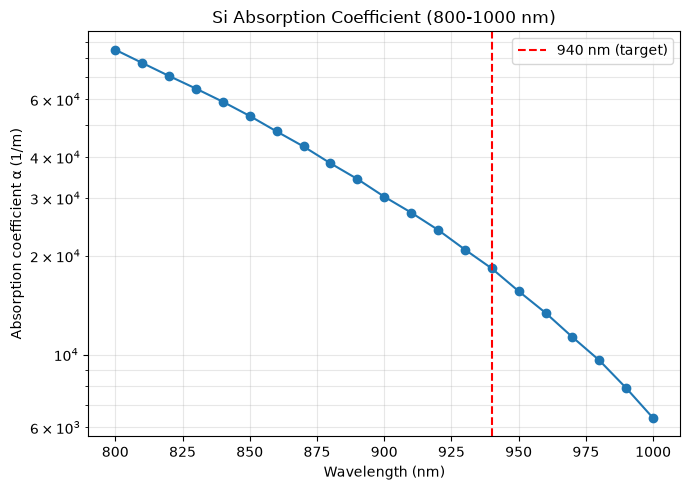

In [2]:
# 흡수계수 alpha = 4*pi*k / lambda 계산
# 파장 단위를 μm -> m 으로 변환해서 계산 (alpha 단위: 1/m)
wl_k_m = wl_k * 1e-6
alpha = 4 * np.pi * k_vals / wl_k_m   # 단위: 1/m

# 800-1000 nm 구간만 잘라서 보기
mask = (wl_k >= 0.8) & (wl_k <= 1.0)

plt.figure(figsize=(7,5))
plt.plot(wl_k[mask]*1000, alpha[mask], marker='o')
plt.yscale('log')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Absorption coefficient α (1/m)')
plt.title('Si Absorption Coefficient (800-1000 nm)')
plt.grid(True, which='both', alpha=0.3)
plt.axvline(940, color='red', linestyle='--', label='940 nm (target)')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/fig1_Si_absorption_baseline.png', dpi=150)
plt.show()

In [3]:
t = 2e-6  # 2 μm 두께
absorptance_estimate = 1 - np.exp(-alpha[mask] * t)

print("940nm 근처 예상 흡수율:")
idx_940 = np.argmin(np.abs(wl_k[mask]*1000 - 940))
print(f"  α = {alpha[mask][idx_940]:.1f} 1/m")
print(f"  두께 2μm에서 흡수율 ≈ {absorptance_estimate[idx_940]*100:.2f} %")

940nm 근처 예상 흡수율:
  α = 18300.1 1/m
  두께 2μm에서 흡수율 ≈ 3.59 %
